# Laboratorio 3. Regresión Lineal Multivariable, Regresión Polinómica y Ecuación de la Normal

Se estiman los parámetros $\theta$ de un modelo de regresión sobre el dataset
`energydata_complete.csv` de tres maneras distintas:

1. **Regresión lineal multivariable** mediante el descenso por el gradiente.
2. **Regresión polinómica** de grado 2 (descenso por el gradiente y solución cerrada con scikit-learn).
3. **Ecuación de la normal** (solución directa en forma cerrada).

Para cada modelo se incluye su **gráfico de costo**, su entrenamiento y su **validación** con
predicciones sobre datos no vistos (más de 100 predicciones), junto con las métricas MSE, RMSE y R².

In [81]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## 1. Descripción del dataset

Se emplea el dataset `energydata_complete.csv`, que registra cada 10 minutos el consumo de energía
de los electrodomésticos de una vivienda (columna objetivo `Appliances`, en Wh) junto con
27 variables de contexto: temperaturas y humedades en distintas zonas, temperatura/humedad exterior,
presión atmosférica, velocidad del viento, visibilidad y otras.

El dataset cumple los requisitos del enunciado: **n = 27 características** y
**m = 19,735 ejemplos**. La columna `date` se elimina por ser temporal y no aportar información
a la regresión, y no existen valores nulos.

In [82]:
df = pd.read_csv('./energydata_complete.csv')

print('Dimensiones del dataset (m filas, n+1 columnas):', df.shape)
print(df.head())

Dimensiones del dataset (m filas, n+1 columnas): (19735, 29)
                  date  Appliances  lights     T1       RH_1    T2       RH_2  \
0  2016-01-11 17:00:00          60      30  19.89  47.596667  19.2  44.790000   
1  2016-01-11 17:10:00          60      30  19.89  46.693333  19.2  44.722500   
2  2016-01-11 17:20:00          50      30  19.89  46.300000  19.2  44.626667   
3  2016-01-11 17:30:00          50      40  19.89  46.066667  19.2  44.590000   
4  2016-01-11 17:40:00          60      40  19.89  46.333333  19.2  44.530000   

      T3       RH_3         T4  ...         T9   RH_9     T_out  Press_mm_hg  \
0  19.79  44.730000  19.000000  ...  17.033333  45.53  6.600000        733.5   
1  19.79  44.790000  19.000000  ...  17.066667  45.56  6.483333        733.6   
2  19.79  44.933333  18.926667  ...  17.000000  45.50  6.366667        733.7   
3  19.79  45.000000  18.890000  ...  17.000000  45.40  6.250000        733.8   
4  19.79  45.000000  18.890000  ...  17.000000  45.4

In [83]:
y = df['Appliances'].values
X_df = df.drop(columns=['date', 'Appliances'])
X = X_df.values

m = y.size
n = X.shape[1]

print(f'Número de instancias (m): {m}')
print(f'Número de características (n): {n}')

print('\nMuestra de los primeros 10 registros:')
print('{:>12s}{:>12s}{:>14s}'.format('X[:, 0]', 'X[:, 1]', 'y (Appliances)'))
print('-' * 40)
for i in range(10):
    print('{:12.2f}{:12.2f}{:14.0f}'.format(X[i, 0], X[i, 1], y[i]))

Número de instancias (m): 19735
Número de características (n): 27

Muestra de los primeros 10 registros:
     X[:, 0]     X[:, 1]y (Appliances)
----------------------------------------
       30.00       19.89            60
       30.00       19.89            60
       30.00       19.89            50
       40.00       19.89            50
       40.00       19.89            60
       40.00       19.89            50
       50.00       19.89            60
       50.00       19.86            60
       40.00       19.79            60
       40.00       19.86            70


## 2. Análisis de correlación

Antes de entrenar se inspecciona la relación de cada característica con la variable objetivo.
Las correlaciones absolutas son bajas (la más alta corresponde a `lights`, ≈ 0.20), por lo que el
desempeño esperado de los modelos será moderado, pero suficiente para demostrar el procedimiento
completo de entrenamiento y validación. Esta baja relación individual también motiva el uso de un
modelo polinómico con interacciones, que pueda capturar relaciones no lineales entre variables.

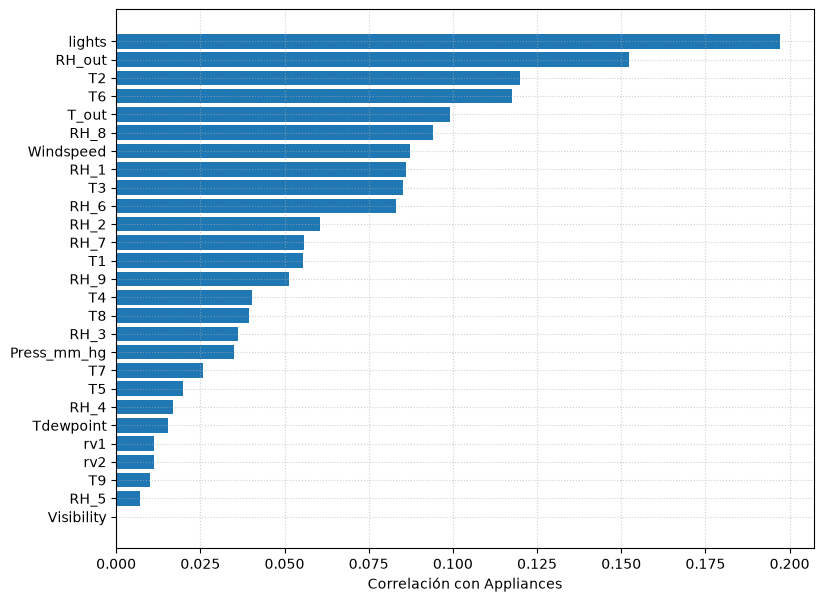

In [84]:
corr = df.corr(numeric_only=True)['Appliances'].drop('Appliances')

fig, ax = plt.subplots(figsize=(9, 7))
corr_abs = corr.abs().sort_values(ascending=True)
ax.barh(corr_abs.index, corr_abs.values)
ax.set_xlabel('Correlación con Appliances')
ax.grid(True, linestyle=':', alpha=0.6)

## 3. Partición entrenamiento/validación

El dataset se divide en 80% de entrenamiento
(15,788 ejemplos) y 20% de validación (3,947 ejemplos). Las predicciones finales
se realizan sobre el conjunto de validación, que el modelo no vio al entrenar.

In [85]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

m_train = y_train.size
m_val = y_val.size

print(f'Tamaño del conjunto de entrenamiento: {m_train}')
print(f'Tamaño del conjunto de validación: {m_val}')
print(f'Forma de X_train: {X_train.shape}')
print(f'Forma de X_val: {X_val.shape}')

Tamaño del conjunto de entrenamiento: 15788
Tamaño del conjunto de validación: 3947
Forma de X_train: (15788, 27)
Forma de X_val: (3947, 27)


## 4. Modelo 1. Regresión Lineal Multivariable (Descenso por el Gradiente)

Se usan las 27 características de forma lineal. Se normalizan las features calculando $\mu$ y $\sigma$ únicamente con el conjunto de entrenamiento y aplicándolas después también a la validación. Luego se agrega el término de intersección $x_0 = 1$.

La función de costo es
$$ J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2 $$
y la regla de actualización del descenso por el gradiente por lotes es
$$ \theta := \theta - \frac{\alpha}{m} X^T (X\theta - y) . $$

Se entrena con $\alpha = 0.01$ y 10,000 iteraciones; el gráfico de costo muestra la convergencia.

In [86]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma


def computeCostMulti(X, y, theta):
    m = y.shape[0]
    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J


def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []
    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))
    return theta, J_history

In [87]:
X_train_norm, mu, sigma = featureNormalize(X_train)

X_train_b = np.concatenate([np.ones((m_train, 1)), X_train_norm], axis=1)
X_val_norm = (X_val - mu) / sigma
X_val_b = np.concatenate([np.ones((m_val, 1)), X_val_norm], axis=1)

alpha = 0.01
num_iters = 10000

theta_dg = np.zeros(X_train_b.shape[1])
theta_dg, J_history_dg = gradientDescentMulti(X_train_b, y_train, theta_dg, alpha, num_iters)

print('theta calculado por el descenso por el gradiente (primeros 5 valores):', theta_dg[:5])
print('Costo inicial J:', J_history_dg[0])
print('Costo final J:', J_history_dg[-1])

theta calculado por el descenso por el gradiente (primeros 5 valores): [ 97.94970864  15.66229353  -7.2750074   57.70639301 -26.52807124]
Costo inicial J: 10003.695952120825
Costo final J: 4455.15144422069


Text(0, 0.5, 'Costo J')

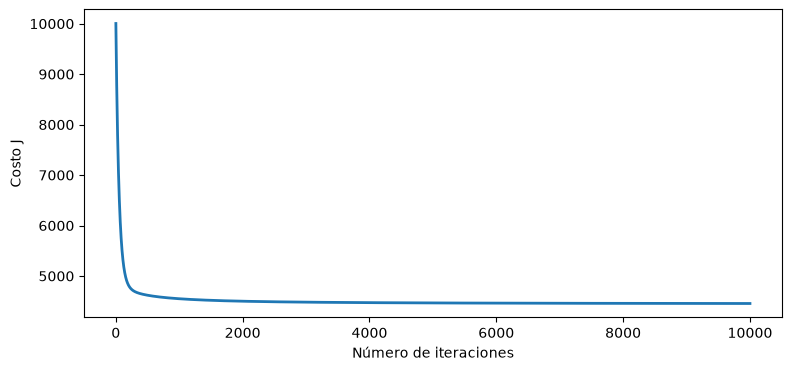

In [88]:
plt.figure(figsize=(9, 4))
plt.plot(np.arange(1, len(J_history_dg) + 1), J_history_dg, color='tab:blue', lw=2)
plt.xlabel('Número de iteraciones')
plt.ylabel('Costo J')

In [89]:
y_pred_dg = np.dot(X_val_b, theta_dg)

mse_dg = mean_squared_error(y_val, y_pred_dg)
rmse_dg = np.sqrt(mse_dg)
r2_dg = r2_score(y_val, y_pred_dg)

print('--- Validación: Regresión Lineal Multivariable (DG) ---')
print(f'Predicciones realizadas sobre validación: {y_pred_dg.size}')
print(f'MSE: {mse_dg:.2f}')
print(f'RMSE: {rmse_dg:.2f}')
print(f'R²: {r2_dg:.4f}')

--- Validación: Regresión Lineal Multivariable (DG) ---
Predicciones realizadas sobre validación: 3947
MSE: 8318.66
RMSE: 91.21
R²: 0.1687


## 5. Modelo 2. Regresión Polinómica de Grado 2

Para capturar relaciones no lineales se amplía la matriz de características con
`PolynomialFeatures(degree=2)`, que genera los términos lineales, los cuadráticos y todas las
interacciones entre pares de variables: las 27 características originales se convierten en
405 características polinómicas.

Este modelo se resuelve de dos formas:

a) Descenso por el gradiente sobre el polinomio normalizado, igual que el Modelo 1 pero con
405 parámetros. Debido a la fuerte colinealidad entre tantas características, la convergencia con
un único ritmo de aprendizaje es más lenta.

b) Solución cerrada con scikit-learn (`LinearRegression` sobre el polinomio), que resuelve los
mínimos cuadrados por SVD y sirve como referencia exacta del óptimo.

In [90]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_val_poly = poly.transform(X_val)

print('Características polinómicas (grado 2), incluye x0:', X_train_poly.shape[1])
print('Forma de X_train_poly:', X_train_poly.shape)
print('Forma de X_val_poly:', X_val_poly.shape)

Características polinómicas (grado 2), incluye x0: 406
Forma de X_train_poly: (15788, 406)
Forma de X_val_poly: (3947, 406)


In [91]:
X_train_poly_norm, mu_poly, sigma_poly = featureNormalize(X_train_poly[:, 1:])
X_train_poly_b = np.concatenate([np.ones((m_train, 1)), X_train_poly_norm], axis=1)

X_val_poly_norm = (X_val_poly[:, 1:] - mu_poly) / sigma_poly
X_val_poly_b = np.concatenate([np.ones((m_val, 1)), X_val_poly_norm], axis=1)

In [92]:
alpha_poly = 0.01
num_iters_poly = 10000

theta_poly = np.zeros(X_train_poly_b.shape[1])
theta_poly, J_history_poly = gradientDescentMulti(X_train_poly_b, y_train, theta_poly, alpha_poly, num_iters_poly)

print('theta polinómico por DG (primeros 5 valores):', theta_poly[:5])
print('Costo inicial J:', J_history_poly[0])
print('Costo final J:', J_history_poly[-1])

theta polinómico por DG (primeros 5 valores): [97.94970864 14.76480162  1.9114261   7.22218252 -7.14202549]
Costo inicial J: 9818.917644637297
Costo final J: 4212.527609417584


Text(0, 0.5, 'Costo J')

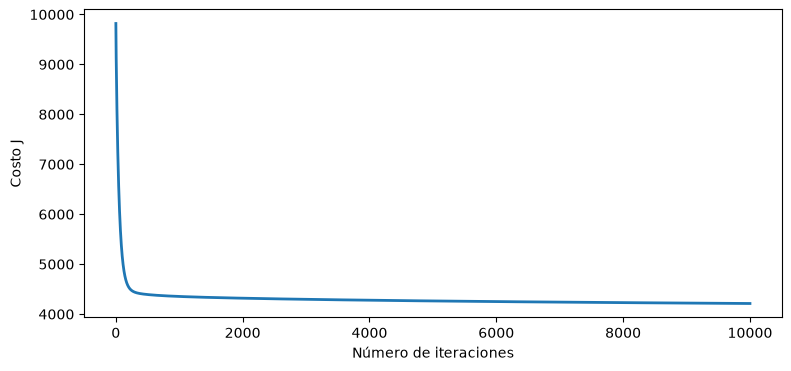

In [103]:
plt.figure(figsize=(9, 4))
plt.plot(np.arange(1, len(J_history_poly) + 1), J_history_poly, lw=2)
plt.xlabel('Número de iteraciones')
plt.ylabel('Costo J')

In [94]:
y_pred_poly_dg = np.dot(X_val_poly_b, theta_poly)

mse_poly_dg = mean_squared_error(y_val, y_pred_poly_dg)
rmse_poly_dg = np.sqrt(mse_poly_dg)
r2_poly_dg = r2_score(y_val, y_pred_poly_dg)

print('--- Validación: Regresión Polinómica (DG) ---')
print(f'MSE: {mse_poly_dg:.2f}')
print(f'RMSE: {rmse_poly_dg:.2f}')
print(f'R²: {r2_poly_dg:.4f}')

--- Validación: Regresión Polinómica (DG) ---
MSE: 7971.28
RMSE: 89.28
R²: 0.2034


In [95]:
reg_poly = LinearRegression()
reg_poly.fit(X_train_poly, y_train)

y_pred_poly = reg_poly.predict(X_val_poly)

mse_poly = mean_squared_error(y_val, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_val, y_pred_poly)

print('theta polinómico por scikit-learn (primeros 5 coeficientes):', reg_poly.coef_[:5])
print('término independiente b:', reg_poly.intercept_)

theta polinómico por scikit-learn (primeros 5 coeficientes): [3.13218535e-11 1.56440747e+01 4.09762046e+00 2.13205729e+01
 9.42405239e+00]
término independiente b: 21201.111543027804


In [96]:
print('--- Validación: Regresión Polinómica (scikit-learn) ---')
print(f'Predicciones realizadas sobre validación: {y_pred_poly.size}')
print(f'MSE: {mse_poly:.2f}')
print(f'RMSE: {rmse_poly:.2f}')
print(f'R²: {r2_poly:.4f}')

--- Validación: Regresión Polinómica (scikit-learn) ---
Predicciones realizadas sobre validación: 3947
MSE: 7229.92
RMSE: 85.03
R²: 0.2775


## 6. Modelo 3. Ecuación de la Normal

La ecuación de la normal obtiene directamente los parámetros óptimos en forma cerrada:
$$ \theta = (X^T X)^{-1} X^T y $$
y no requiere normalización de las características.

Como $X^TX$ es singular por la colinealidad existente (`rv1` = `rv2`), se utiliza la
**pseudoinversa** (`pinv`) para obtener una solución numéricamente estable. Este modelo se aplica
sobre las 27 características lineales (agregando $x_0 = 1$), y su costo final se compara con el de
los otros dos modelos en la sección siguiente.

In [97]:
def normalEqn(X, y):
    theta = np.dot(np.linalg.pinv(np.dot(X.T, X)), np.dot(X.T, y))
    return theta

In [98]:
X_train_ne = np.concatenate([np.ones((m_train, 1)), X_train], axis=1)
X_val_ne = np.concatenate([np.ones((m_val, 1)), X_val], axis=1)

theta_ne = normalEqn(X_train_ne, y_train)

print('theta calculado por la ecuación de la normal (primeros 5 valores):', theta_ne[:5])

J_ne = computeCostMulti(X_train_ne, y_train, theta_ne)
print(f'Costo final J (entrenamiento): {J_ne:.2f}')

theta calculado por la ecuación de la normal (primeros 5 valores): [ 23.12113113   1.93024717   0.07481057  15.90604363 -17.59690443]
Costo final J (entrenamiento): 4448.97


In [99]:
y_pred_ne = np.dot(X_val_ne, theta_ne)

mse_ne = mean_squared_error(y_val, y_pred_ne)
rmse_ne = np.sqrt(mse_ne)
r2_ne = r2_score(y_val, y_pred_ne)

print('--- Validación: Ecuación de la Normal ---')
print(f'Predicciones realizadas sobre validación: {y_pred_ne.size}')
print(f'MSE: {mse_ne:.2f}')
print(f'RMSE: {rmse_ne:.2f}')
print(f'R²: {r2_ne:.4f}')

--- Validación: Ecuación de la Normal ---
Predicciones realizadas sobre validación: 3947
MSE: 8312.85
RMSE: 91.17
R²: 0.1693


## 7. Comparación de modelos y predicciones

Se comparan los tres modelos sobre el conjunto de validación (3,947 muestras). Se muestran: **(a)** el costo final de entrenamiento de cada caso,
**(b)** las primeras 150 predicciones de cada modelo contra los valores reales y **(c)** una tabla
resumen de las métricas MSE, RMSE y R² calculadas sobre validación.

In [100]:
J_dg = computeCostMulti(X_train_b, y_train, theta_dg)
J_poly_dg = computeCostMulti(X_train_poly_b, y_train, theta_poly)

print('Costo final J (entrenamiento) por modelo:')
print(f'  Regresión lineal multivariable (DG):  {J_dg:.2f}')
print(f'  Regresión polinómica grado 2 (DG):    {J_poly_dg:.2f}')
print(f'  Ecuación de la normal:                {J_ne:.2f}')

Costo final J (entrenamiento) por modelo:
  Regresión lineal multivariable (DG):  4455.15
  Regresión polinómica grado 2 (DG):    4212.53
  Ecuación de la normal:                4448.97


Total de predicciones realizadas sobre el conjunto de validación: 3947
Predicciones graficadas: 150


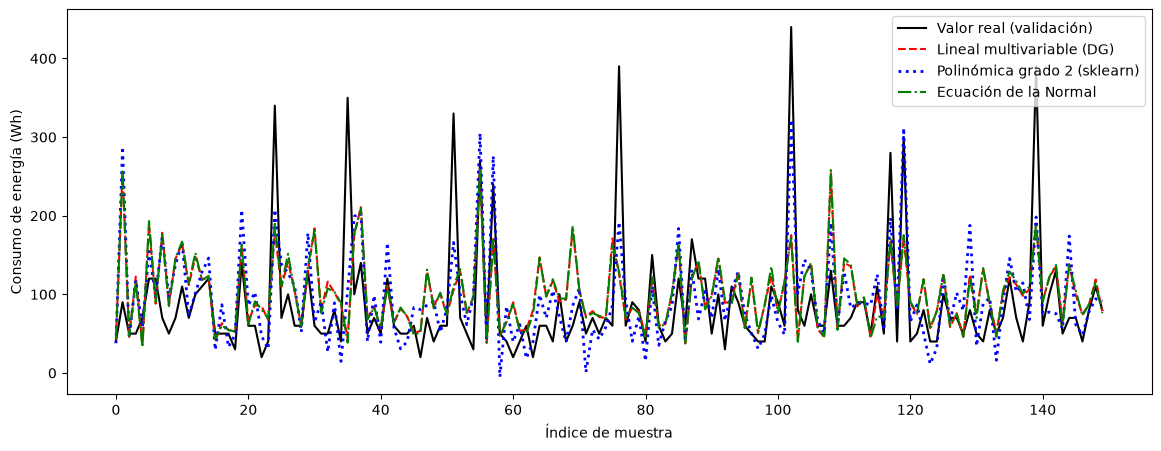

In [102]:
n_pred = 150
idx = np.arange(n_pred)

plt.figure(figsize=(14, 5))
plt.plot(idx, y_val[:n_pred], 'k-', linewidth=1.5, label='Valor real (validación)')
plt.plot(idx, y_pred_dg[:n_pred], 'r--', label='Lineal multivariable (DG)')
plt.plot(idx, y_pred_poly[:n_pred], 'b:', linewidth=2, label='Polinómica grado 2 (sklearn)')
plt.plot(idx, y_pred_ne[:n_pred], 'g-.', label='Ecuación de la Normal')
plt.xlabel('Índice de muestra')
plt.ylabel('Consumo de energía (Wh)')
plt.legend()

print(f'Total de predicciones realizadas sobre el conjunto de validación: {m_val}')
print(f'Predicciones graficadas: {n_pred}')